# Analisis Attrition Karyawan (Employee Attrition Analysis)

Notebook ini bertujuan untuk melakukan analisis data, persiapan data, pemodelan, dan evaluasi untuk memprediksi kemungkinan karyawan keluar (attrition). Analisis ini mengikuti logika yang digunakan dalam aplikasi produksi project ini.

## 1. Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Memuat dataset
df = pd.read_csv('../data/employee_data_final.csv')
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Dataset loaded with 1470 rows and 31 columns.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,38,0,Travel_Frequently,1444,Human Resources,1,4,Other,4,Male,...,3,2,1,7,2,3,6,2,1,2
1,37,1,Travel_Rarely,1141,Research & Development,11,2,Medical,1,Female,...,3,1,0,15,2,1,1,0,0,0
2,51,1,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,Male,...,3,3,3,18,2,4,10,0,2,7
3,42,0,Travel_Frequently,555,Sales,26,3,Marketing,3,Female,...,3,4,1,23,2,4,20,4,4,8
4,40,0,Travel_Rarely,1194,Research & Development,2,4,Medical,3,Female,...,3,2,3,20,2,3,5,3,0,2


## 2. Exploratory Data Analysis (EDA)

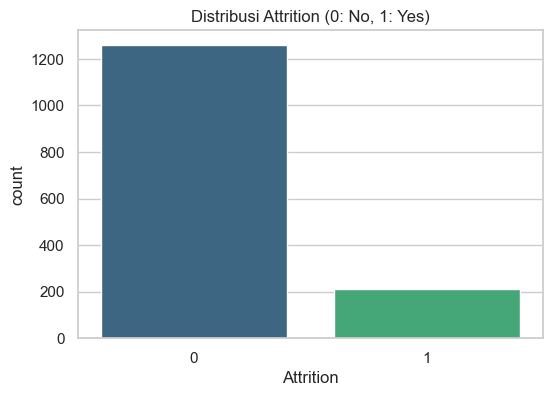

Attrition
0    85.714286
1    14.285714
Name: proportion, dtype: float64


In [3]:
# Cek distribusi target (Attrition)
plt.figure(figsize=(6, 4))
sns.countplot(x='Attrition', data=df, palette='viridis')
plt.title('Distribusi Attrition (0: No, 1: Yes)')
plt.show()

print(df['Attrition'].value_counts(normalize=True) * 100)

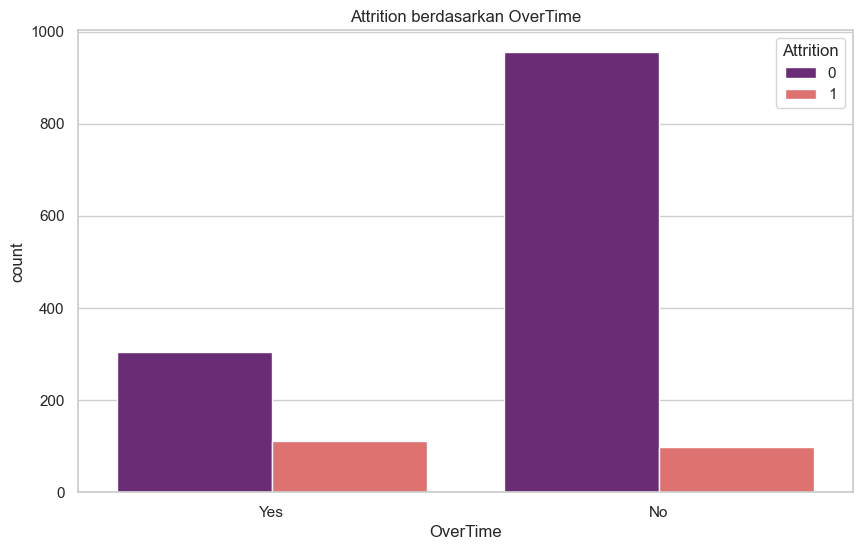

In [4]:
# Hubungan OverTime dengan Attrition
sns.countplot(x='OverTime', hue='Attrition', data=df, palette='magma')
plt.title('Attrition berdasarkan OverTime')
plt.show()

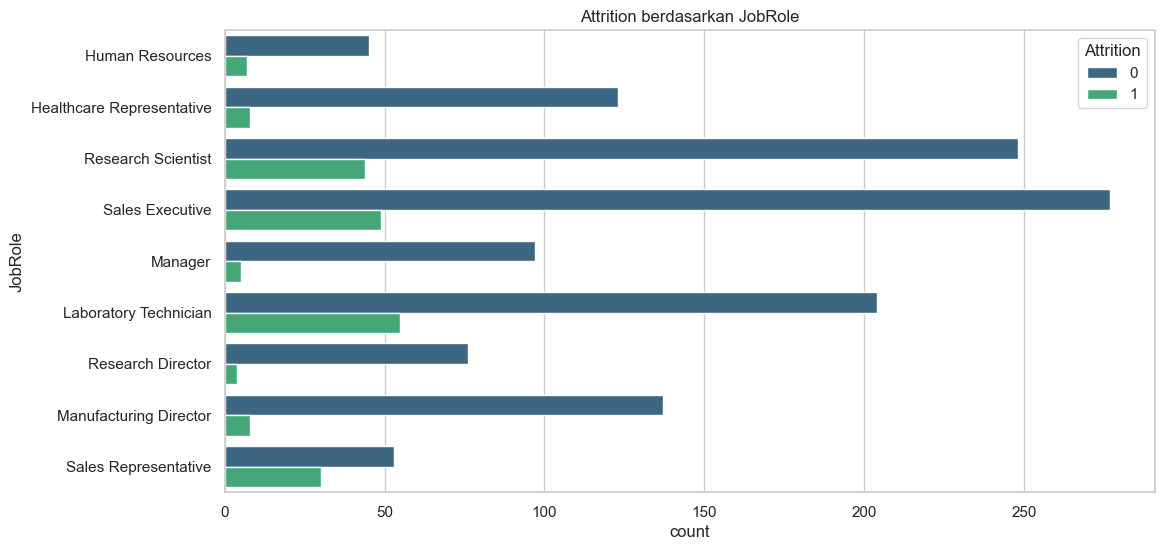

In [5]:
# Hubungan JobRole dengan Attrition
plt.figure(figsize=(12, 6))
sns.countplot(y='JobRole', hue='Attrition', data=df, palette='viridis')
plt.title('Attrition berdasarkan JobRole')
plt.show()

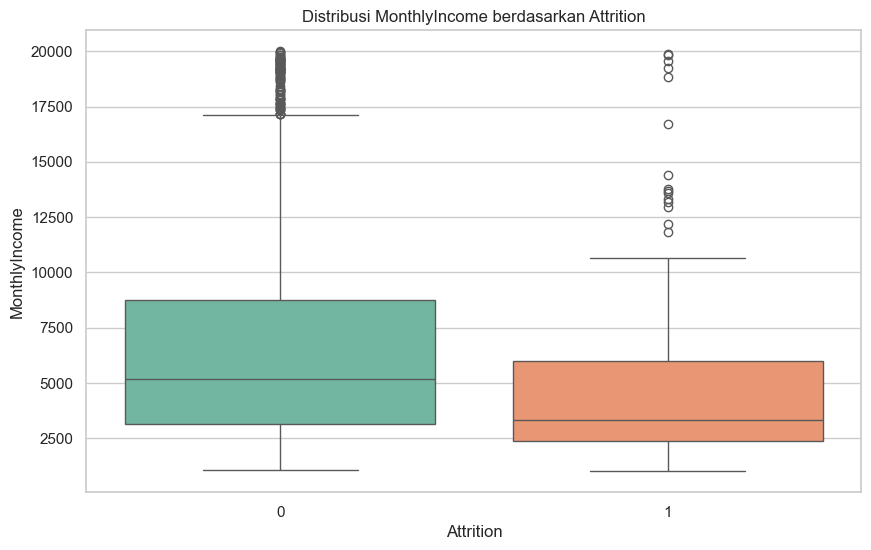

In [6]:
# Hubungan MonthlyIncome dengan Attrition
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='Set2')
plt.title('Distribusi MonthlyIncome berdasarkan Attrition')
plt.show()

## 3. Data Preparation

In [7]:
# Sesuai dengan app/model_loader.py, kita hapus kolom yang tidak relevan
cols_to_drop = ['Attrition', 'EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
X = df.drop(columns=cols_to_drop, errors='ignore')
y = df['Attrition'].astype(int)

print(f"Fitur yang digunakan: {X.columns.tolist()}")

Fitur yang digunakan: ['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [8]:
# One-Hot Encoding untuk variabel kategori
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Shape setelah encoding: {X_encoded.shape}")

Shape setelah encoding: (1470, 44)


In [9]:
# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")

Training set: 1176 rows
Testing set: 294 rows


## 4. Modeling

In [10]:
# Inisialisasi Model (Sesuai dengan project: RandomForest dengan class_weight='balanced')
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

print("Model Random Forest berhasil dilatih.")

Model Random Forest berhasil dilatih.


## 5. Evaluation

In [11]:
# Menggunakan Threshold 0.40 (Sesuai Logika Bisnis di Project)
threshold = 0.40
probs = model.predict_proba(X_test)[:, 1]
predictions = (probs >= threshold).astype(int)

# Hitung Metrik
acc = accuracy_score(y_test, predictions)
prec = precision_score(y_test, predictions)
rec = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
auc = roc_auc_score(y_test, probs)

print(f"--- Metrik Evaluasi (Threshold: {threshold}) ---")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc:.4f}")

--- Metrik Evaluasi (Threshold: 0.4) ---
Accuracy  : 0.8741
Precision : 0.5385
Recall    : 0.1842
F1-Score  : 0.2745
AUC-ROC   : 0.7527


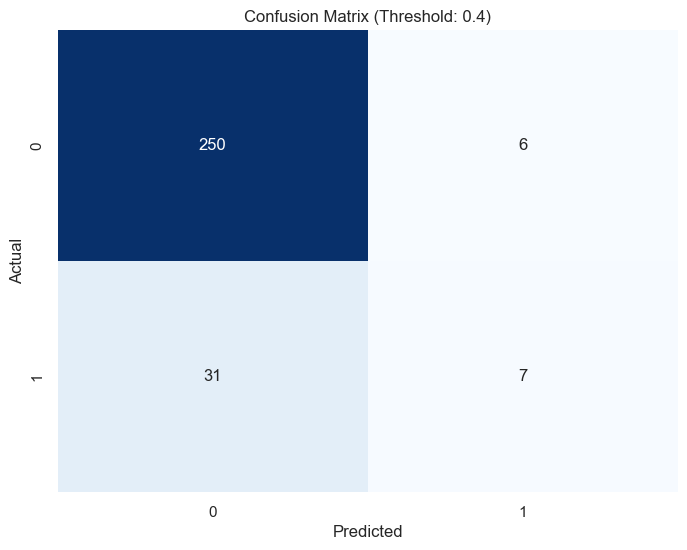

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Threshold: {threshold})')
plt.show()

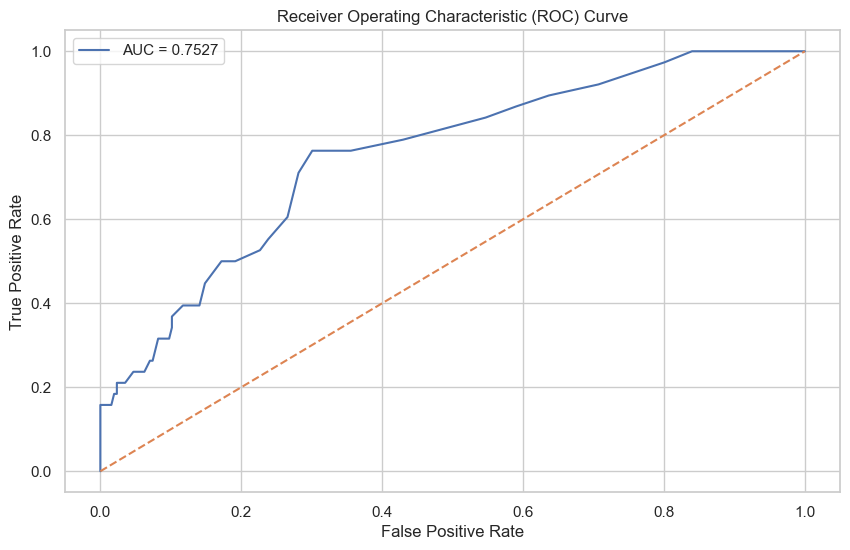

In [13]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs)
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

## 6. Feature Importance

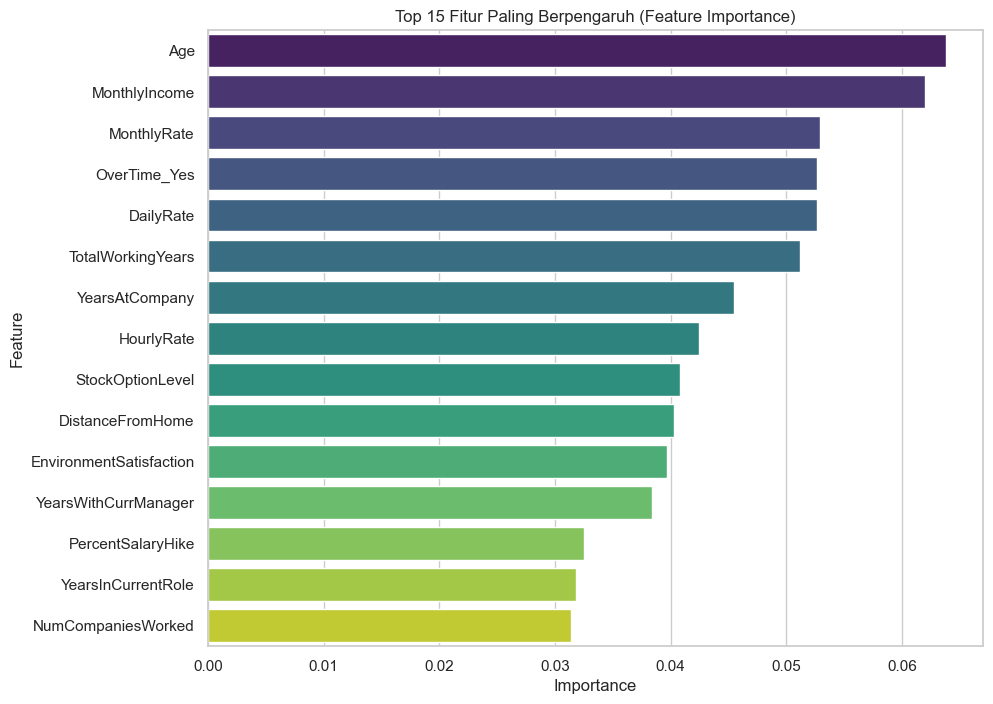

In [14]:
# Visualisasi Fitur Paling Berpengaruh
importances = model.feature_importances_
feature_names = X_encoded.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 15 Fitur Paling Berpengaruh (Feature Importance)')
plt.show()